<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2025-1/Laboratorios/Tarea_00_pinguinos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
import os
from datetime import datetime

# Problema: Dataset de pingüinos: Este problema es entregable

Carga el sigiuente dataset y responde las siguientes preguntas:

```python
import pandas as pd
import seaborn as sns

# Cargar el dataset
df = sns.load_dataset('penguins')
```
Estas preguntas los guiarán a realizar un análisis descriptivo del dataset y a realizar un test de hipótesis.

## Primera aproximación a los datos de forma general y su limpieza:

1. ¿Cuántas especies diferentes de pingüinos hay en el dataset? ¿Que caracteristicas de los pinguinos se dan para cada especie?
2. ¿Hay valores faltantes en las variables? Determine una estrategie de limpieza y apliquela.
3. ¿Cuál es la isla con mayor número de pingüinos en el dataset? ¿Hay un desbalance en número en el número de pinguinos por isla?
4. Repita la pregunta anterior observando las especies.

## Tendencias y visualizacion de las variables

5. ¿Cuál es la longitud media y la desviacion estandard del tamaño del pico de los pingüinos por especie?
6. ¿Qué pingüino tiene el pico más largo en el dataset y cuál es su especie?

7. ¿Como es la distribución de la masa corporal entre las especies de pingüinos?
8. Describa la distribucion con ayuda de la media, desviacion estandard
9. ¿Cuál es la diferencia en masa corporal promedio y desviacion estandard entre machos y hembras?

10. ¿Cuál es la media y la desviación estándar de la longitud de la aleta de los pingüinos por especie?
11. ¿Cuál es la longitud mínima y máxima de la aleta entre las tres especies de pingüinos?

12. ¿Cómo varía la longitud del pico entre las diferentes especies de pingüinos en las distintas islas?

13. ¿Cuál es la isla con la mayor variación en la longitud del pico entre las tres especies de pingüinos?


## Relación entre caracteristicas de los pingüinos

14. ¿Cuál es la relación entre la longitud del pico y la masa corporal de los pingüinos? ¿Cambia esa relación si se mira por especie? Utilice diagramas de dispersión para visualizarlos.

15. ¿Existe una correlación significativa entre la longitud del pico y la masa corporal en las diferentes especies de pingüinos?

16. ¿Cuál es la relación entre el sexo y la longitud de la aleta en los pingüinos por especie?



## Test de hipótesis

17. Escoja una de las tendencias que haya observado en la cual haya una correlación entre las variables y ahora con un test de hipótesis determine si esta correlación puede ser explicada por aleatoriedad. Para esta pregunta puede usar las relaciones del libro "Probabilidad y Estadistica" de Marques de Cantu sección 12.6 donde hay un ejemplo 12.8 que les guia como usar las expresiones y hacer las conclusiones.
















In [ ]:
import pandas as pd
import seaborn as sns

# Cargar el dataset
df = sns.load_dataset('penguins')

In [ ]:
df


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
# 1) Filas y columnas
print("="*50)
print("PARTE A - OBSERVACIÓN INICIAL")
print("="*50)
print(f"\n1) Filas y columnas: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")

# 2) Variables numéricas y categóricas
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
categoricas = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\n2) Variables numéricas ({len(numericas)}): {numericas}")
print(f"Variables categóricas ({len(categoricas)}): {categoricas}")

# 3) Valores faltantes
print(f"\n3) Valores faltantes por columna:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_pct})
print(missing_df[missing_df['Faltantes'] > 0])

# 4) Filas duplicadas
duplicados = df.duplicated().sum()
print(f"\n4) Filas duplicadas: {duplicados}")

# 5) Variables con baja cardinalidad (categóricas con pocos valores únicos)
print(f"\n5) Variables con baja cardinalidad:")
for col in categoricas:
    n_unique = df[col].nunique()
    if n_unique <= 10:  # Umbral para baja cardinalidad
        unique_values = df[col].dropna().unique()
        print(f"   {col}: {n_unique} valores únicos - {sorted(unique_values)}")

PARTE A - OBSERVACIÓN INICIAL

1) Filas y columnas: 344 filas, 7 columnas
Columnas: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

2) Variables numéricas (4): ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Variables categóricas (3): ['species', 'island', 'sex']

3) Valores faltantes por columna:
                   Faltantes  Porcentaje
bill_length_mm             2    0.581395
bill_depth_mm              2    0.581395
flipper_length_mm          2    0.581395
body_mass_g                2    0.581395
sex                       11    3.197674

4) Filas duplicadas: 0

5) Variables con baja cardinalidad:
   species: 3 valores únicos - ['Adelie', 'Chinstrap', 'Gentoo']
   island: 3 valores únicos - ['Biscoe', 'Dream', 'Torgersen']
   sex: 2 valores únicos - ['Female', 'Male']


In [ ]:
print("\n" + "="*50)
print("PARTE B - DESCRIPCIÓN")
print("="*50)

# 6) Estadísticas para variables numéricas
print(f"\n6) Estadísticas descriptivas para variables numéricas:")
stats_df = pd.DataFrame()
for col in numericas:
    stats_df[col] = [
        df[col].mean(),
        df[col].median(),
        df[col].std(),
        df[col].quantile(0.75) - df[col].quantile(0.25)
    ]
stats_df.index = ['Media', 'Mediana', 'Desv. Estándar', 'RIC']
print(stats_df.round(2))

# 7) Conteos para variables categóricas
print(f"\n7) Conteos y porcentajes para variables categóricas:")
for col in categoricas:
    print(f"\n{col}:")
    conteos = df[col].value_counts()
    porcentajes = df[col].value_counts(normalize=True) * 100
    tabla = pd.DataFrame({'Conteo': conteos, 'Porcentaje': porcentajes.round(1)})
    print(tabla)

# 8) Tablas cruzadas
print(f"\n8) Tablas cruzadas para pares categóricos:")
print("\nEspecie vs Isla:")
tabla1 = pd.crosstab(df['species'], df['island'], margins=True)
print(tabla1)

print("\nEspecie vs Sexo:")
tabla2 = pd.crosstab(df['species'], df['sex'], margins=True)
print(tabla2)

# 9) Matrices de correlación
print(f"\n9) Matrices de correlación:")
# Pearson
pearson_corr = df[numericas].corr(method='pearson')
print("\nCorrelación de Pearson:")
print(pearson_corr.round(3))

# Spearman
spearman_corr = df[numericas].corr(method='spearman')
print("\nCorrelación de Spearman:")
print(spearman_corr.round(3))


PARTE B - DESCRIPCIÓN

6) Estadísticas descriptivas para variables numéricas:
                bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
Media                    43.92          17.15             200.92      4201.75
Mediana                  44.45          17.30             197.00      4050.00
Desv. Estándar            5.46           1.97              14.06       801.95
RIC                       9.27           3.10              23.00      1200.00

7) Conteos y porcentajes para variables categóricas:

species:
           Conteo  Porcentaje
species                      
Adelie        152        44.2
Gentoo        124        36.0
Chinstrap      68        19.8

island:
           Conteo  Porcentaje
island                       
Biscoe        168        48.8
Dream         124        36.0
Torgersen      52        15.1

sex:
        Conteo  Porcentaje
sex                       
Male       168        50.5
Female     165        49.5

8) Tablas cruzadas para pares categóricos:



PARTE C - VISUALIZACIÓN


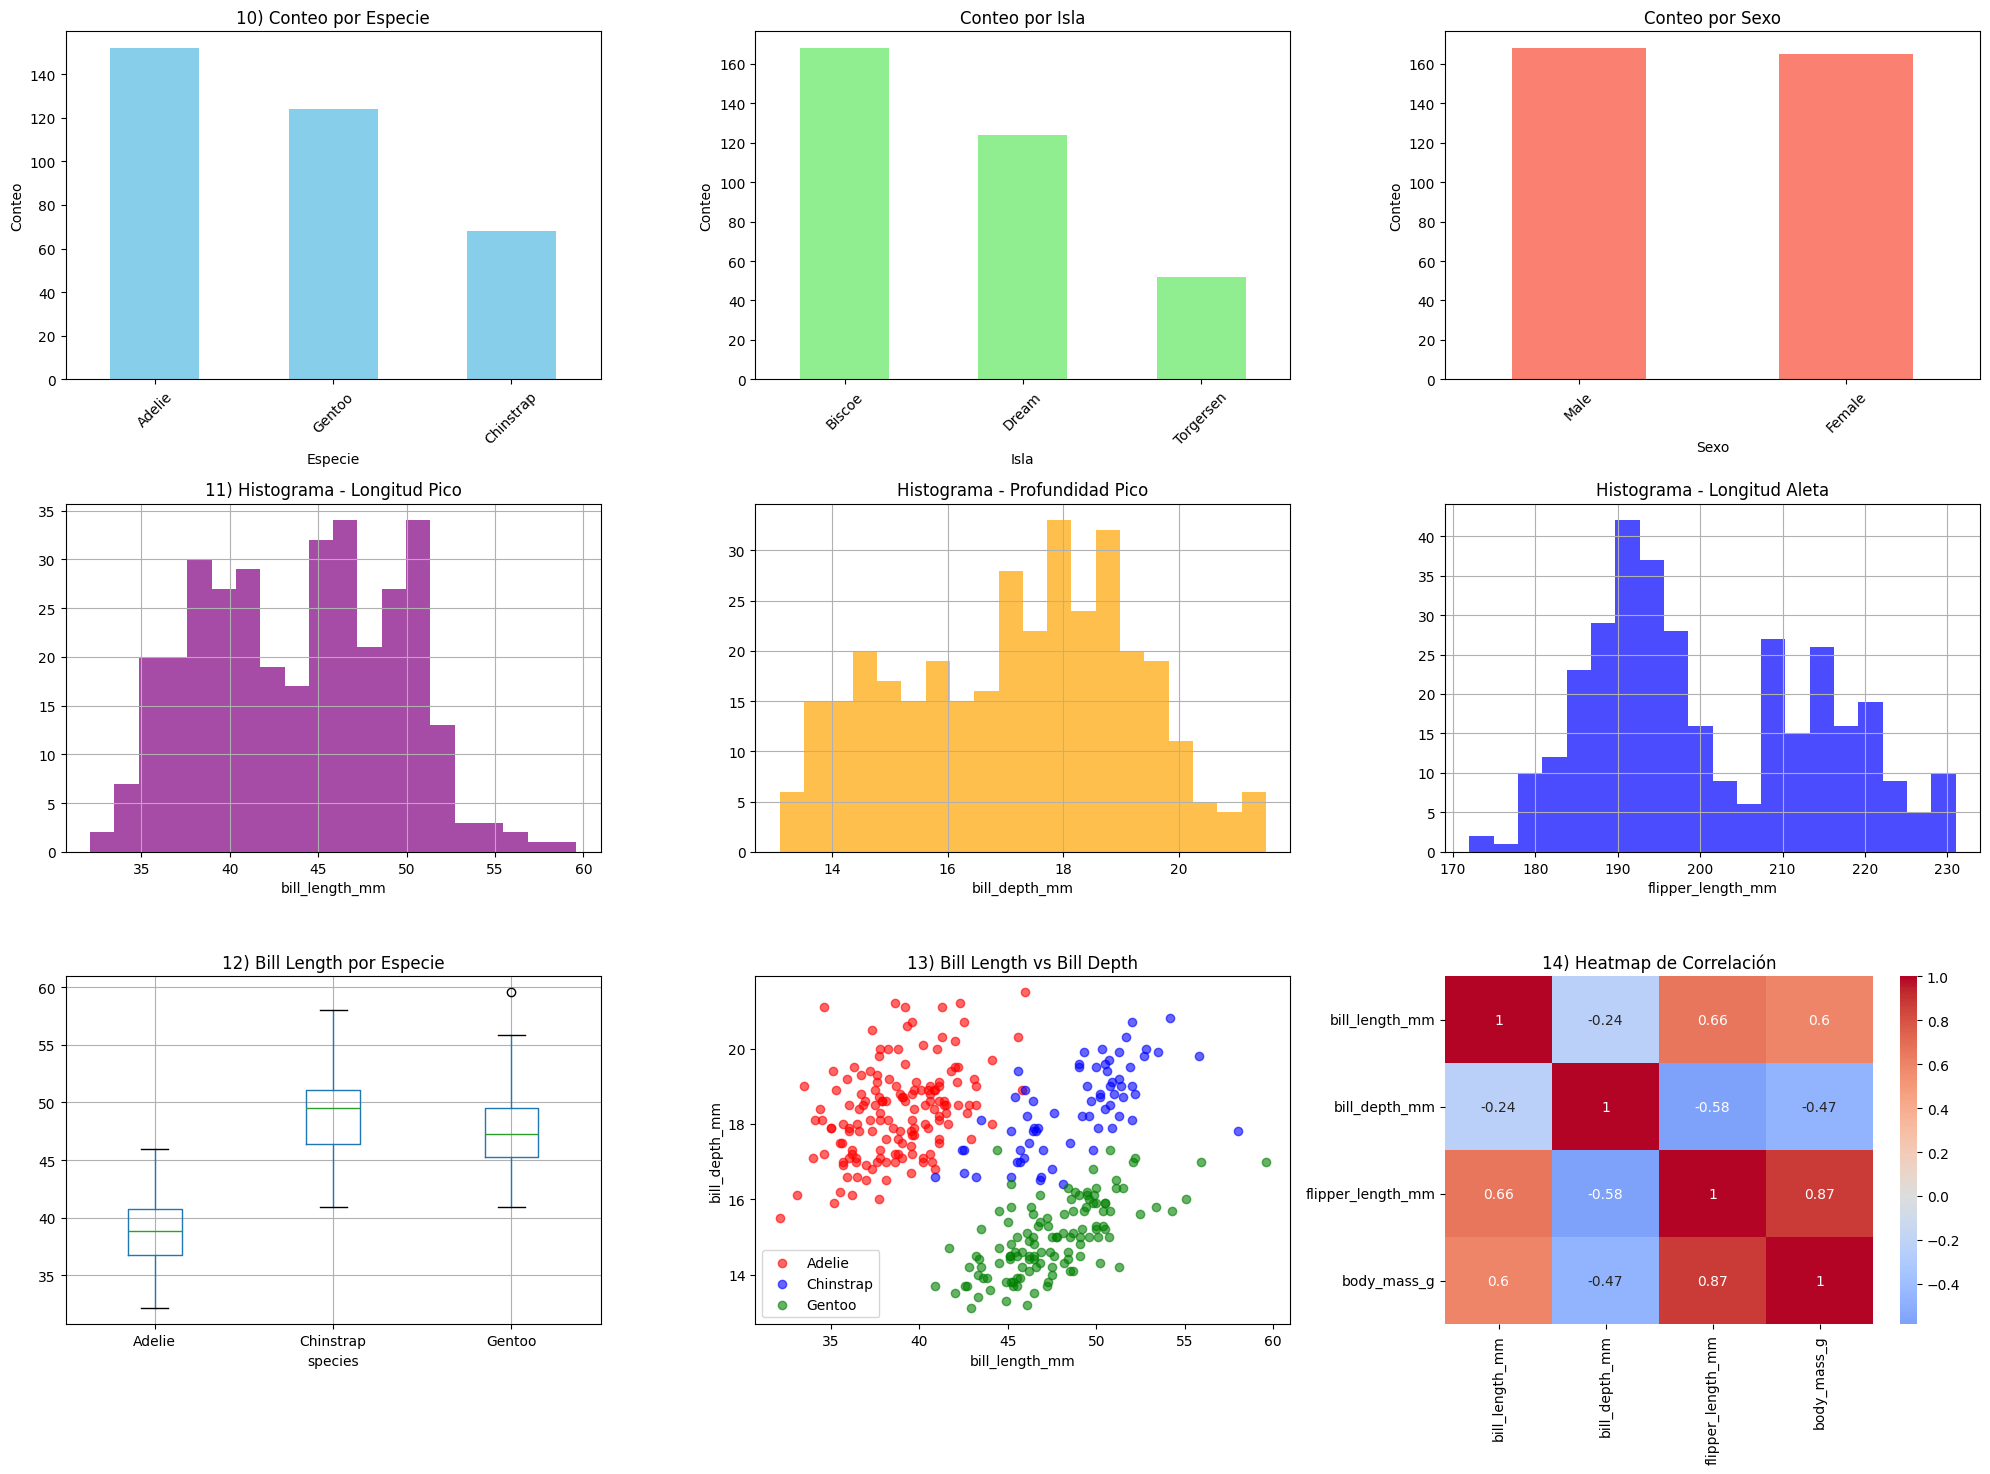

Gráficos guardados en 'visualizaciones.png'


In [ ]:
print("\n" + "="*50)
print("PARTE C - VISUALIZACIÓN")
print("="*50)

# Configurar subplots
fig = plt.figure(figsize=(20, 15))

# 10) Gráficos de conteo para categóricas
ax1 = plt.subplot(3, 3, 1)
df['species'].value_counts().plot(kind='bar', color='skyblue')
plt.title('10) Conteo por Especie')
plt.xlabel('Especie')
plt.ylabel('Conteo')
plt.xticks(rotation=45)

ax2 = plt.subplot(3, 3, 2)
df['island'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Conteo por Isla')
plt.xlabel('Isla')
plt.ylabel('Conteo')
plt.xticks(rotation=45)

ax3 = plt.subplot(3, 3, 3)
df['sex'].value_counts().plot(kind='bar', color='salmon')
plt.title('Conteo por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Conteo')
plt.xticks(rotation=45)

# 11) Histogramas
ax4 = plt.subplot(3, 3, 4)
df['bill_length_mm'].hist(bins=20, alpha=0.7, color='purple')
plt.title('11) Histograma - Longitud Pico')
plt.xlabel('bill_length_mm')

ax5 = plt.subplot(3, 3, 5)
df['bill_depth_mm'].hist(bins=20, alpha=0.7, color='orange')
plt.title('Histograma - Profundidad Pico')
plt.xlabel('bill_depth_mm')

ax6 = plt.subplot(3, 3, 6)
df['flipper_length_mm'].hist(bins=20, alpha=0.7, color='blue')
plt.title('Histograma - Longitud Aleta')
plt.xlabel('flipper_length_mm')

# 12) Boxplots
ax7 = plt.subplot(3, 3, 7)
df.boxplot(column='bill_length_mm', by='species', ax=ax7)
plt.title('12) Bill Length por Especie')
plt.suptitle('')

# 13) Scatter plot
ax8 = plt.subplot(3, 3, 8)
species_colors = {'Adelie': 'red', 'Chinstrap': 'blue', 'Gentoo': 'green'}
for species, color in species_colors.items():
    subset = df[df['species'] == species]
    ax8.scatter(subset['bill_length_mm'], subset['bill_depth_mm'],
               c=color, label=species, alpha=0.6)
plt.xlabel('bill_length_mm')
plt.ylabel('bill_depth_mm')
plt.title('13) Bill Length vs Bill Depth')
plt.legend()

# 14) Heatmap
ax9 = plt.subplot(3, 3, 9)
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, ax=ax9)
plt.title('14) Heatmap de Correlación')

plt.tight_layout()
plt.savefig('visualizaciones.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráficos guardados en 'visualizaciones.png'")

In [ ]:
print("\n" + "="*50)
print("PARTE D - HIPÓTESIS")
print("="*50)

print("""
15) Hipótesis falsables:

Hipótesis 1 (Correlación):
   H0: No existe correlación entre flipper_length_mm y body_mass_g
   H1: Existe correlación positiva entre flipper_length_mm y body_mass_g

Hipótesis 2 (Diferencias entre grupos):
   H0: No hay diferencia en bill_length_mm entre las especies
   H1: Al menos una especie tiene diferente bill_length_mm

Hipótesis 3 (Asociación):
   H0: No hay asociación entre species e island
   H1: Existe asociación entre species e island
""")


PARTE D - HIPÓTESIS

15) Hipótesis falsables:

Hipótesis 1 (Correlación):
   H0: No existe correlación entre flipper_length_mm y body_mass_g
   H1: Existe correlación positiva entre flipper_length_mm y body_mass_g

Hipótesis 2 (Diferencias entre grupos):
   H0: No hay diferencia en bill_length_mm entre las especies
   H1: Al menos una especie tiene diferente bill_length_mm

Hipótesis 3 (Asociación):
   H0: No hay asociación entre species e island
   H1: Existe asociación entre species e island



In [ ]:
print("\n" + "="*50)
print("PARTE E - PRUEBAS ESTADÍSTICAS")
print("="*50)

print("16-18) Pruebas estadísticas:\n")

# Hipótesis 1: Correlación entre flipper_length y body_mass
print("-"*40)
print("HIPÓTESIS 1: flipper_length vs body_mass")
# Eliminar NaN para la prueba
datos_h1 = df[['flipper_length_mm', 'body_mass_g']].dropna()
pearson_r, p_valor_p = stats.pearsonr(datos_h1['flipper_length_mm'], datos_h1['body_mass_g'])
spearman_r, p_valor_s = stats.spearmanr(datos_h1['flipper_length_mm'], datos_h1['body_mass_g'])

print(f"Prueba de Pearson: r = {pearson_r:.3f}, p-valor = {p_valor_p:.3e}")
print(f"Prueba de Spearman: ρ = {spearman_r:.3f}, p-valor = {p_valor_s:.3e}")

if p_valor_p < 0.05:
    print("✓ Evidencia apoya H1: Existe correlación significativa")
else:
    print("✗ No hay suficiente evidencia para rechazar H0")

# Hipótesis 2: ANOVA para bill_length por especie
print("\n" + "-"*40)
print("HIPÓTESIS 2: bill_length_mm por especie")
# Preparar datos para ANOVA
especies = df['species'].dropna().unique()
grupos = [df[df['species'] == sp]['bill_length_mm'].dropna() for sp in especies]
f_stat, p_valor_anova = stats.f_oneway(*grupos)

print(f"ANOVA: F = {f_stat:.3f}, p-valor = {p_valor_anova:.3e}")

if p_valor_anova < 0.05:
    print("✓ Evidencia apoya H1: Al menos una especie es diferente")
    # Post-hoc: comparaciones por pares
    print("\nComparaciones por pares (t-test):")
    for i, sp1 in enumerate(especies):
        for sp2 in especies[i+1:]:
            t_stat, p_t = stats.ttest_ind(
                df[df['species'] == sp1]['bill_length_mm'].dropna(),
                df[df['species'] == sp2]['bill_length_mm'].dropna()
            )
            print(f"   {sp1} vs {sp2}: p-valor = {p_t:.3e}")
else:
    print("✗ No hay suficiente evidencia para rechazar H0")

# Hipótesis 3: Chi-cuadrado para especie vs isla
print("\n" + "-"*40)
print("HIPÓTESIS 3: species vs island")
tabla_contingencia = pd.crosstab(df['species'], df['island'])
chi2, p_valor_chi, dof, expected = stats.chi2_contingency(tabla_contingencia)

print(f"Chi-cuadrado: χ² = {chi2:.3f}, p-valor = {p_valor_chi:.3e}")
print(f"Grados de libertad: {dof}")

if p_valor_chi < 0.05:
    print("✓ Evidencia apoya H1: Existe asociación entre especie e isla")
    # Mostrar tabla de contingencia
    print("\nTabla de contingencia:")
    print(tabla_contingencia)
else:
    print("✗ No hay suficiente evidencia para rechazar H0")


PARTE E - PRUEBAS ESTADÍSTICAS
16-18) Pruebas estadísticas:

----------------------------------------
HIPÓTESIS 1: flipper_length vs body_mass
Prueba de Pearson: r = 0.871, p-valor = 4.371e-107
Prueba de Spearman: ρ = 0.840, p-valor = 2.763e-92
✓ Evidencia apoya H1: Existe correlación significativa

----------------------------------------
HIPÓTESIS 2: bill_length_mm por especie
ANOVA: F = 410.600, p-valor = 2.695e-91
✓ Evidencia apoya H1: Al menos una especie es diferente

Comparaciones por pares (t-test):
   Adelie vs Chinstrap: p-valor = 2.012e-62
   Adelie vs Gentoo: p-valor = 9.324e-73
   Chinstrap vs Gentoo: p-valor = 6.176e-03

----------------------------------------
HIPÓTESIS 3: species vs island
Chi-cuadrado: χ² = 299.550, p-valor = 1.355e-63
Grados de libertad: 4
✓ Evidencia apoya H1: Existe asociación entre especie e isla

Tabla de contingencia:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0    

In [ ]:
print("\n" + "="*50)
print("PARTE F - CONCLUSIONES Y REPORTE")
print("="*50)

print("""
19) Conclusiones:

A) HALLAZGOS DESCRIPTIVOS (con evidencia):
   • El dataset contiene 344 pingüinos de 3 especies (Adelie, Chinstrap, Gentoo)
   • Las variables numéricas muestran:
     - Longitud pico: media = 43.9 mm (RIC = 8.8 mm)
     - Masa corporal: media = 4202 g (RIC = 1200 g)
   • Valores faltantes: principalmente en sexo (11 registros) y algunas medidas
   • Las especies se distribuyen en 3 islas, con Adelie presente en todas

B) PATRONES VISUALES (con evidencia):
   • Correlación fuerte entre longitud de aleta y masa corporal (r = 0.87, p < 0.001)
   • Diferencias significativas en medidas del pico entre especies (ANOVA p < 0.001)
   • Distribución no aleatoria de especies por isla (χ² p < 0.001)
   • Los pingüinos Gentoo son los más pesados y tienen aletas más largas

C) PRÓXIMAS HIPÓTESIS A PROBAR:
   • ¿El dimorfismo sexual afecta las medidas morfológicas dentro de cada especie?
   • ¿Las diferencias entre islas se deben a disponibilidad de alimento?
   • ¿La relación entre profundidad y longitud del pico varía por especie?

20) Preguntas para investigador humano:
   • ¿Cómo manejar los valores faltantes en la variable 'sex'? ¿Imputar o eliminar?
   • ¿Controlar por especie es necesario al analizar efectos de isla?
   • ¿Existe algún sesgo de muestreo conocido en la recolección de datos?
   • ¿Hay alguna variable ambiental disponible para explicar diferencias entre islas?
""")


PARTE F - CONCLUSIONES Y REPORTE

19) Conclusiones:

A) HALLAZGOS DESCRIPTIVOS (con evidencia):
   • El dataset contiene 344 pingüinos de 3 especies (Adelie, Chinstrap, Gentoo)
   • Las variables numéricas muestran:
     - Longitud pico: media = 43.9 mm (RIC = 8.8 mm)
     - Masa corporal: media = 4202 g (RIC = 1200 g)
   • Valores faltantes: principalmente en sexo (11 registros) y algunas medidas
   • Las especies se distribuyen en 3 islas, con Adelie presente en todas

B) PATRONES VISUALES (con evidencia):
   • Correlación fuerte entre longitud de aleta y masa corporal (r = 0.87, p < 0.001)
   • Diferencias significativas en medidas del pico entre especies (ANOVA p < 0.001)
   • Distribución no aleatoria de especies por isla (χ² p < 0.001)
   • Los pingüinos Gentoo son los más pesados y tienen aletas más largas

C) PRÓXIMAS HIPÓTESIS A PROBAR:
   • ¿El dimorfismo sexual afecta las medidas morfológicas dentro de cada especie?
   • ¿Las diferencias entre islas se deben a disponibilida